# HAB Strategy Backtest Analysis

这个 notebook 会读取标准化后的 `hab_bars.csv`，运行 `HorizontalAccumulationBreakoutV1`，并生成你选择的 B 方案图表：

- 权益曲线
- 回撤曲线
- 单笔交易盈亏分布
- 退出原因统计
- 信号漏斗 / 拒绝原因统计
- 指定品种价格图 + 开平仓点位
- 风险估计偏差图

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == "note":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from strats.horizontal_accumulation_breakout_v1 import HABConfig, HorizontalAccumulationBreakoutV1

In [ ]:
# Backtest inputs
hab_bars_path = repo_root / "data" / "cache" / "normalized" / "hab_bars.csv"

# 留空表示全品种；也可以填 ['CU', 'AU', 'IF']
symbols = []

# 价格图使用的品种
focus_symbol = "CU"

# 留空表示用全历史；也可以填 '2020-01-01'
start_date = None
end_date = None

# 数据质量处理：'clamp' / 'drop' / 'strict'
data_quality_mode = "clamp"

# 只覆盖你想改的参数
config_overrides = {
    # "initial_capital": 1_000_000,
    "risk_per_trade": 0.04,
    "portfolio_risk_cap": 0.15,
     "group_risk_cap": 0.06,
    "box_lookback": 7,
    "box_width_atr_mult": 1.5,
    "tol_atr_mult": 0.25,
    "breakout_atr_mult": 0.5,
    "upper_shadow_ratio_max": 0.25,
    "initial_stop_atr_mult": 0.4,

    "risk_per_trade": 0.02,
    "portfolio_risk_cap": 0.12,
    "group_risk_cap": 0.06,
    "structure_fail_bars": 15,
    "time_fail_bars": 5,
    "time_fail_target_r": 0.5,
    "trail_activate_r": 1.0,
    "trail_atr_mult": 2.0,
}

In [13]:
bars = pd.read_csv(hab_bars_path, parse_dates=["date"])
bars = bars.sort_values(["date", "symbol"]).reset_index(drop=True)

if symbols:
    selected_symbols = [symbol.strip().upper() for symbol in symbols]
    bars = bars.loc[bars["symbol"].isin(selected_symbols)].copy()

if start_date is not None:
    bars = bars.loc[bars["date"] >= pd.Timestamp(start_date)].copy()
if end_date is not None:
    bars = bars.loc[bars["date"] <= pd.Timestamp(end_date)].copy()

if bars.empty:
    raise ValueError("No bars left after applying filters.")

ohlc_upper = bars[["open", "close"]].max(axis=1)
ohlc_lower = bars[["open", "close"]].min(axis=1)
invalid_ohlc_mask = (bars["high"] < ohlc_upper) | (bars["low"] > ohlc_lower)
invalid_rows = bars.loc[invalid_ohlc_mask, ["date", "symbol", "open", "high", "low", "close"]].copy()

print(f"invalid OHLC rows: {len(invalid_rows):,}")
if not invalid_rows.empty:
    print(invalid_rows["symbol"].value_counts().head(10).to_string())

backtest_bars = bars.copy()
if data_quality_mode == "clamp":
    backtest_bars.loc[invalid_ohlc_mask, "high"] = backtest_bars.loc[invalid_ohlc_mask, ["high", "open", "close"]].max(axis=1)
    backtest_bars.loc[invalid_ohlc_mask, "low"] = backtest_bars.loc[invalid_ohlc_mask, ["low", "open", "close"]].min(axis=1)
elif data_quality_mode == "drop":
    backtest_bars = backtest_bars.loc[~invalid_ohlc_mask].copy()
elif data_quality_mode == "strict":
    pass
else:
    raise ValueError("data_quality_mode must be one of: 'clamp', 'drop', 'strict'")

if backtest_bars.empty:
    raise ValueError("No bars left after data quality handling.")

available_symbols = sorted(bars["symbol"].unique())
focus_symbol = focus_symbol.strip().upper()
if focus_symbol not in available_symbols:
    examples = ", ".join(available_symbols[:30])
    raise ValueError(f"focus_symbol {focus_symbol!r} is not in filtered bars. examples: {examples}")

print(f"rows: {len(bars):,}")
print(f"symbols: {bars['symbol'].nunique():,}")
print(f"date range: {bars['date'].min().date()} -> {bars['date'].max().date()}")
print(f"backtest rows after quality handling: {len(backtest_bars):,}")
backtest_bars.head()

invalid OHLC rows: 144
symbol
RS    62
WH    21
BB    21
JR    10
RI     9
ZC     7
PM     6
FB     4
LR     3
WR     1
rows: 135,638
symbols: 91
date range: 2018-01-02 -> 2025-12-31
backtest rows after quality handling: 135,638


,date,symbol,open,high,low,close,volume,open_interest,contract_multiplier,commission,slippage,group_name
0,2018-01-02,A,2813.00,2898.00,2813.00,2869.00,92242.0,233118.0,10.0,5.0,1.00,commodity
1,2018-01-02,AG,4577.00,4588.00,4569.00,4580.00,137022.0,602744.0,15.0,5.0,1.00,commodity
2,2018-01-02,AL,13270.00,13465.00,13025.00,13090.00,250552.0,296254.0,5.0,5.0,1.00,commodity
3,2018-01-02,AP,4178.00,4196.00,4176.00,4191.00,16426.0,12360.0,10.0,5.0,1.00,commodity
4,2018-01-02,AU,343.37,343.72,342.77,343.22,54760.0,255972.0,1000.0,10.0,0.05,precious


In [14]:
cfg = HABConfig(**config_overrides)
engine = HorizontalAccumulationBreakoutV1(cfg)
result = engine.run(backtest_bars)

trades = result.trades.copy()
daily_status = result.daily_status.copy()
portfolio_daily = result.portfolio_daily.copy()
open_positions = result.open_positions.copy()
cancelled_entries = result.cancelled_entries.copy()

portfolio_daily["date"] = pd.to_datetime(portfolio_daily["date"])
if not trades.empty:
    for col in ["signal_date", "entry_date", "entry_fill_date", "exit_date"]:
        if col in trades.columns:
            trades[col] = pd.to_datetime(trades[col])
if not cancelled_entries.empty:
    for col in ["signal_date", "entry_date", "entry_fill_date", "cancel_date"]:
        if col in cancelled_entries.columns:
            cancelled_entries[col] = pd.to_datetime(cancelled_entries[col])

portfolio_daily.head()

,date,cash,equity,open_positions,pending_entries,open_risk,portfolio_risk_cap,accepted_signal_risk_today
0,2018-01-02,1000000.0,1000000.0,0,0,0.0,150000.0,0.0
1,2018-01-03,1000000.0,1000000.0,0,0,0.0,150000.0,0.0
2,2018-01-04,1000000.0,1000000.0,0,0,0.0,150000.0,0.0
3,2018-01-05,1000000.0,1000000.0,0,0,0.0,150000.0,0.0
4,2018-01-08,1000000.0,1000000.0,0,0,0.0,150000.0,0.0


In [15]:
equity = portfolio_daily["equity"].astype(float)
running_peak = equity.cummax()
drawdown = equity / running_peak - 1.0

summary = {
    "final_equity": float(equity.iloc[-1]),
    "total_return_pct": float((equity.iloc[-1] / equity.iloc[0] - 1.0) * 100.0),
    "max_drawdown_pct": float(drawdown.min() * 100.0),
    "closed_trades": int(len(trades)),
    "open_positions": int(len(open_positions)),
    "cancelled_entries": int(len(cancelled_entries)),
}

if not trades.empty:
    wins = (trades["net_pnl"] > 0).sum()
    summary["win_rate_pct"] = float(wins / len(trades) * 100.0)
    summary["avg_net_pnl"] = float(trades["net_pnl"].mean())
    summary["avg_r_multiple"] = float(trades["r_multiple"].mean())
else:
    summary["win_rate_pct"] = np.nan
    summary["avg_net_pnl"] = np.nan
    summary["avg_r_multiple"] = np.nan

pd.Series(summary)

final_equity         835855.350567
total_return_pct        -16.414465
max_drawdown_pct        -45.081378
closed_trades            66.000000
open_positions            0.000000
cancelled_entries         0.000000
win_rate_pct             42.424242
avg_net_pnl           -2487.040143
avg_r_multiple            0.238295
dtype: float64

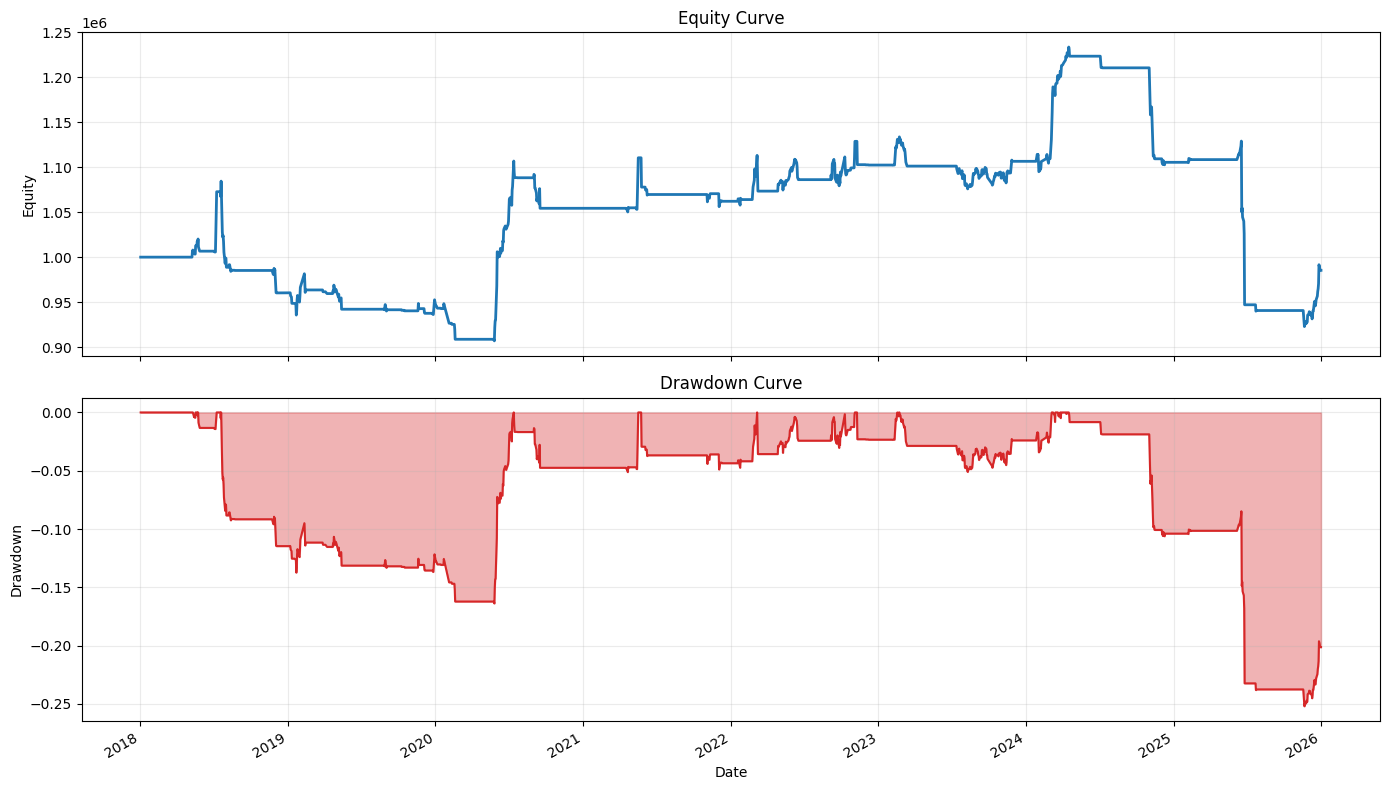

In [6]:
# 1 + 2: 权益曲线与回撤曲线
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(portfolio_daily["date"], equity, linewidth=2)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("Equity")
axes[0].grid(True, alpha=0.25)

axes[1].fill_between(portfolio_daily["date"], drawdown, 0, alpha=0.35, color="tab:red")
axes[1].plot(portfolio_daily["date"], drawdown, color="tab:red", linewidth=1.5)
axes[1].set_title("Drawdown Curve")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].grid(True, alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

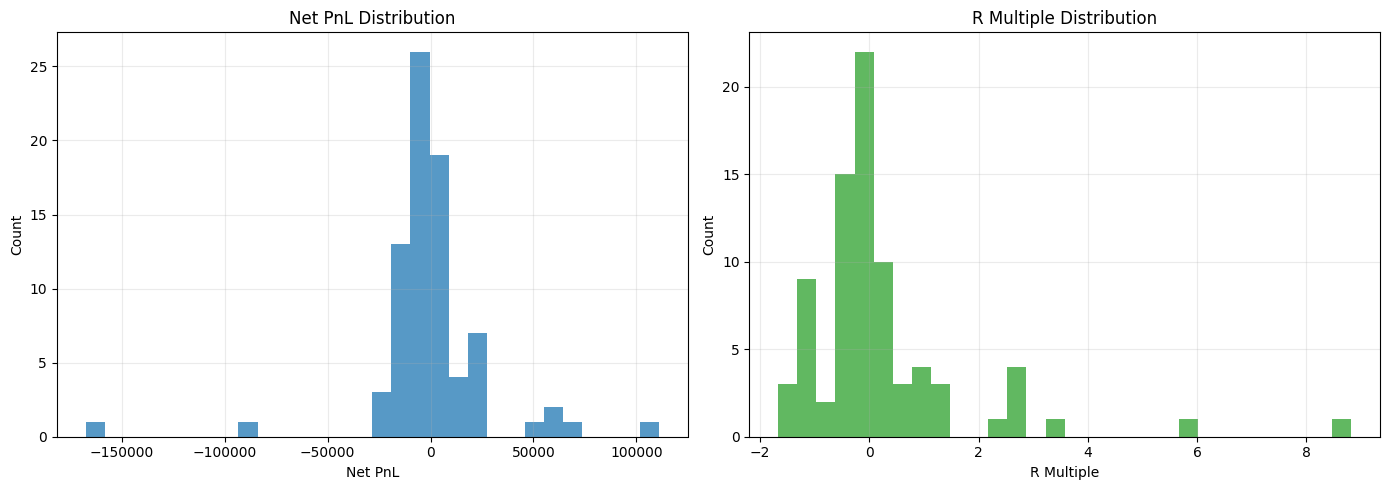

In [7]:
# 4: 单笔交易盈亏分布
if trades.empty:
    print("No closed trades available for distribution plots.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(trades["net_pnl"], bins=30, alpha=0.75, color="tab:blue")
    axes[0].set_title("Net PnL Distribution")
    axes[0].set_xlabel("Net PnL")
    axes[0].set_ylabel("Count")
    axes[0].grid(True, alpha=0.25)

    axes[1].hist(trades["r_multiple"], bins=30, alpha=0.75, color="tab:green")
    axes[1].set_title("R Multiple Distribution")
    axes[1].set_xlabel("R Multiple")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()

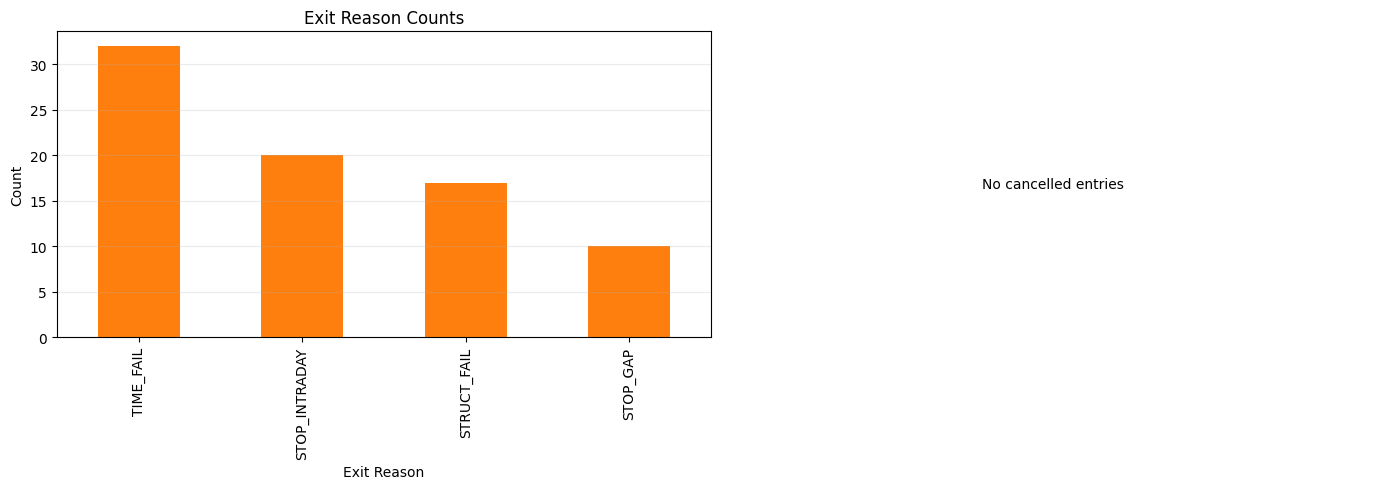

In [8]:
# 5: 退出原因统计 + 取消原因统计
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exit_reason_counts = trades["exit_reason"].value_counts().sort_values(ascending=False) if not trades.empty else pd.Series(dtype=int)
cancel_reason_counts = cancelled_entries["cancel_reason"].value_counts().sort_values(ascending=False) if not cancelled_entries.empty else pd.Series(dtype=int)

if exit_reason_counts.empty:
    axes[0].text(0.5, 0.5, "No closed trades", ha="center", va="center")
    axes[0].set_axis_off()
else:
    exit_reason_counts.plot(kind="bar", ax=axes[0], color="tab:orange")
    axes[0].set_title("Exit Reason Counts")
    axes[0].set_xlabel("Exit Reason")
    axes[0].set_ylabel("Count")
    axes[0].grid(True, axis="y", alpha=0.25)

if cancel_reason_counts.empty:
    axes[1].text(0.5, 0.5, "No cancelled entries", ha="center", va="center")
    axes[1].set_axis_off()
else:
    cancel_reason_counts.plot(kind="bar", ax=axes[1], color="tab:purple")
    axes[1].set_title("Cancelled Entry Reason Counts")
    axes[1].set_xlabel("Cancel Reason")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

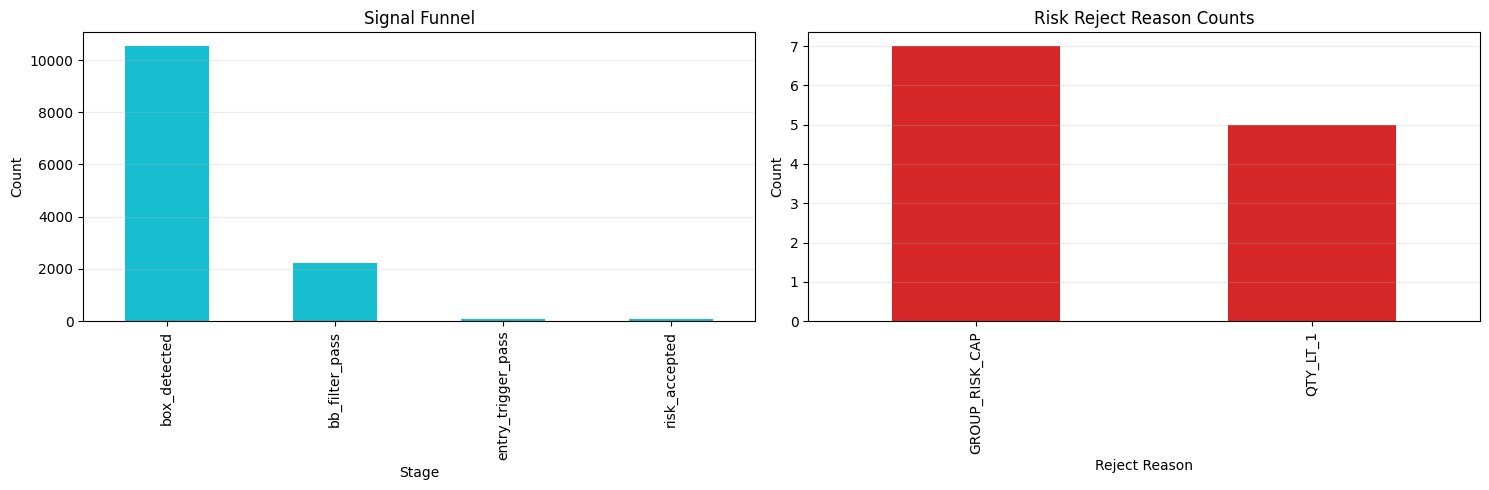

In [9]:
# 7: 信号漏斗 / 拒绝原因统计
funnel_counts = pd.Series(
    {
        "box_detected": int(daily_status["is_box"].fillna(False).sum()),
        "bb_filter_pass": int((daily_status["is_box"].fillna(False) & daily_status["bb_filter_pass"].fillna(False)).sum()),
        "entry_trigger_pass": int((daily_status["entry_trigger_pass"].fillna(False)).sum()),
        "risk_accepted": int((daily_status["entry_trigger_pass"].fillna(False) & daily_status["risk_reject_reason"].isna()).sum()),
    }
)

reject_reason_counts = daily_status["risk_reject_reason"].dropna().value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
funnel_counts.plot(kind="bar", ax=axes[0], color="tab:cyan")
axes[0].set_title("Signal Funnel")
axes[0].set_xlabel("Stage")
axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", alpha=0.25)

if reject_reason_counts.empty:
    axes[1].text(0.5, 0.5, "No risk rejects", ha="center", va="center")
    axes[1].set_axis_off()
else:
    reject_reason_counts.plot(kind="bar", ax=axes[1], color="tab:red")
    axes[1].set_title("Risk Reject Reason Counts")
    axes[1].set_xlabel("Reject Reason")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

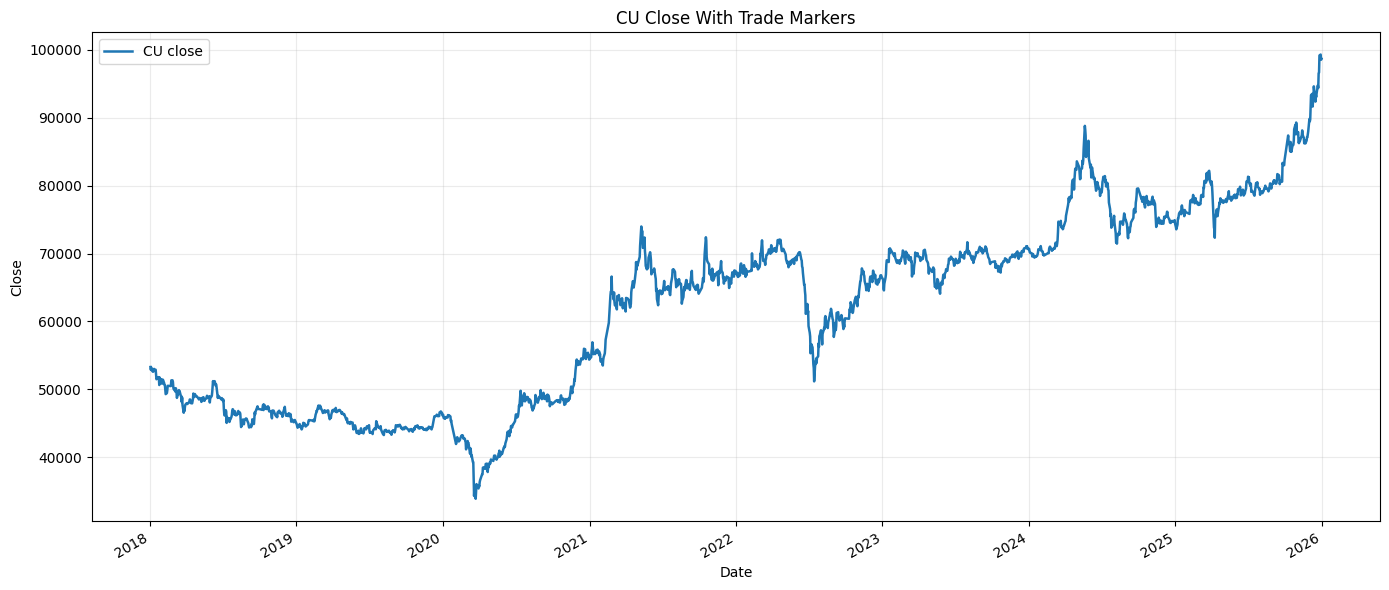

In [11]:
# 8: 指定品种价格图 + 开平仓点位
focus_bars = backtest_bars.loc[backtest_bars["symbol"] == focus_symbol].sort_values("date").copy()
focus_trades = trades.loc[trades["symbol"] == focus_symbol].copy() if not trades.empty else pd.DataFrame()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(focus_bars["date"], focus_bars["close"], label=f"{focus_symbol} close", linewidth=1.8)

if not focus_trades.empty:
    ax.scatter(
        focus_trades["entry_fill_date"],
        focus_trades["entry_fill"],
        marker="^",
        s=70,
        label="Entry",
        color="tab:green",
        zorder=5,
    )
    ax.scatter(
        focus_trades["exit_date"],
        focus_trades["exit_fill"],
        marker="v",
        s=70,
        label="Exit",
        color="tab:red",
        zorder=5,
    )

ax.set_title(f"{focus_symbol} Close With Trade Markers")
ax.set_xlabel("Date")
ax.set_ylabel("Close")
ax.grid(True, alpha=0.25)
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

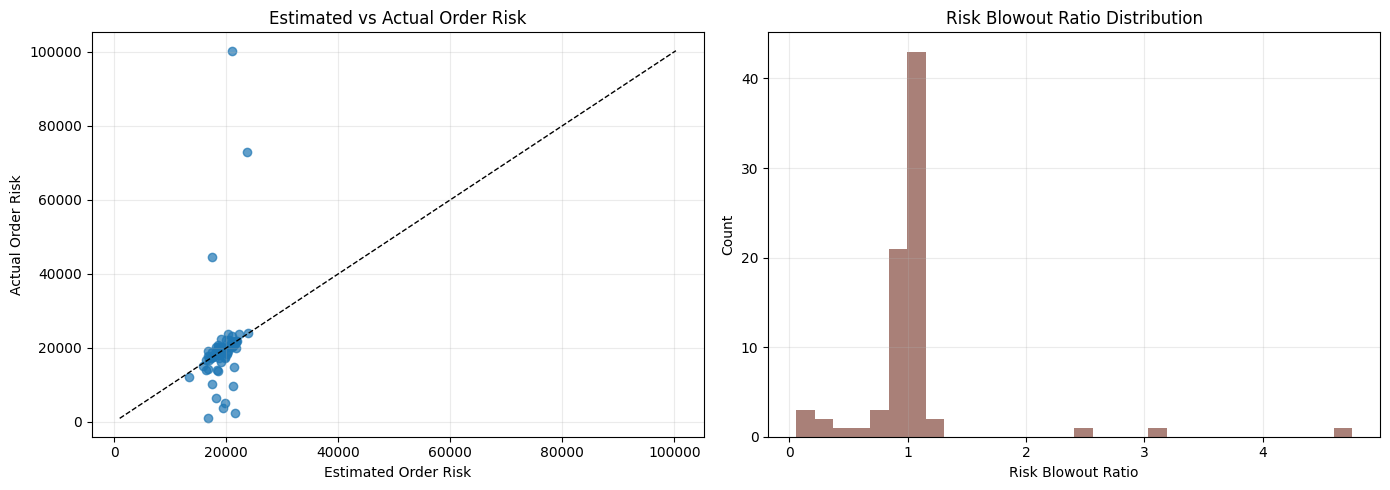

In [10]:
# 10: 风险估计偏差图
if trades.empty:
    print("No closed trades available for risk bias plots.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = trades["estimated_order_risk"].astype(float)
    y = trades["actual_order_risk"].astype(float)
    low = float(min(x.min(), y.min()))
    high = float(max(x.max(), y.max()))

    axes[0].scatter(x, y, alpha=0.7)
    axes[0].plot([low, high], [low, high], linestyle="--", color="black", linewidth=1)
    axes[0].set_title("Estimated vs Actual Order Risk")
    axes[0].set_xlabel("Estimated Order Risk")
    axes[0].set_ylabel("Actual Order Risk")
    axes[0].grid(True, alpha=0.25)

    axes[1].hist(trades["risk_blowout_ratio"].astype(float), bins=30, alpha=0.75, color="tab:brown")
    axes[1].set_title("Risk Blowout Ratio Distribution")
    axes[1].set_xlabel("Risk Blowout Ratio")
    axes[1].set_ylabel("Count")
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()